 <b><i> additional_plots </i></b>

Created by Eduardo Alastrué de Asenjo 

- Purpose: additional supplementary plots not included in .py scripts

Load modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.path as mpath
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Polygon
import re
import math as math
import netCDF4 as nc
from scipy import stats
from random import choices
import copy
import dask
import dask.array as da
import xarray as xr
import pandas as pd
import datetime
import cftime
from tqdm import tqdm
import glob
import pickle
import cdo 
import statsmodels.api as sm 
import xclim as xc
import eofs
import xesmf as xe
import nc_time_axis
import cf_xarray as cfxr
import regionmask
import warnings
import json
warnings.filterwarnings("ignore", category=RuntimeWarning)

run local dask cluster

In [ ]:
from dask.distributed import Client
client = Client(memory_limit=None, threads_per_worker=1, n_workers=18)

load functions

In [ ]:
def weighted_mon_to_year_mean(ds, var):
    """
    weight by days in each month when doing annual mean from monthly values in xarray
    taken from https://ncar.github.io/esds/posts/2021/yearly-averages-xarray/
    """
    month_length = ds.time.dt.days_in_month # Determine the month length

    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum() # Calculate the weights

    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0) # Make sure the weights in each year add up to 1

    obs = ds[var] # Subset our dataset for our variable

    cond = obs.isnull() # Setup our masking for nan values
    ones = xr.where(cond, 0.0, 1.0)
    
    obs_sum = (obs * wgts).resample(time="YS").sum(dim="time") # Calculate the numerator
    ones_out = (ones * wgts).resample(time="YS").sum(dim="time") # Calculate the denominator

    return obs_sum / ones_out # Return the weighted average

In [ ]:
def weighted_area_lat(ds):
    """
    Calculate the area-weighted temperature over its domain. 
    In a regular latitude/ longitude grid the grid cell area decreases towards the pole.
    We can use the cosine of the latitude as proxy for the grid cell area.
    IMPORTANT: after applying function, do .mean('lat') before 'lon'
    Taken from https://docs.xarray.dev/en/stable/examples/area_weighted_temperature.html
    """
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"

    return ds.weighted(weights)

In [ ]:
def reset_djf_time(ds):
    '''
    Function to change xarray dates back to the January of a given winter, after 
    .resample(time='QS-DEC').mean(dim='time'), & .sel(time=seas.time.dt.season=='DJF')
    '''
    def change_month(date):
        return cftime.DatetimeProlepticGregorian(date.year + 1, 1, date.day)
        return date
    new_time = [change_month(date) for date in ds['time'].values]
    ds['time'] = new_time
    return ds

# Supplementary plots

## Hosing forcings plot (Fig. A1)

In [ ]:
# Define colors for the different hosing experiments
colors = {
        'neg01': 'midnightblue',
        '01': 'steelblue',
        '03': 'cornflowerblue',
        '05': 'deepskyblue',
        'linneg02': 'teal',
        'lin02': 'cadetblue',
        'lin06': 'mediumaquamarine',
        'lin10': 'aquamarine'
}

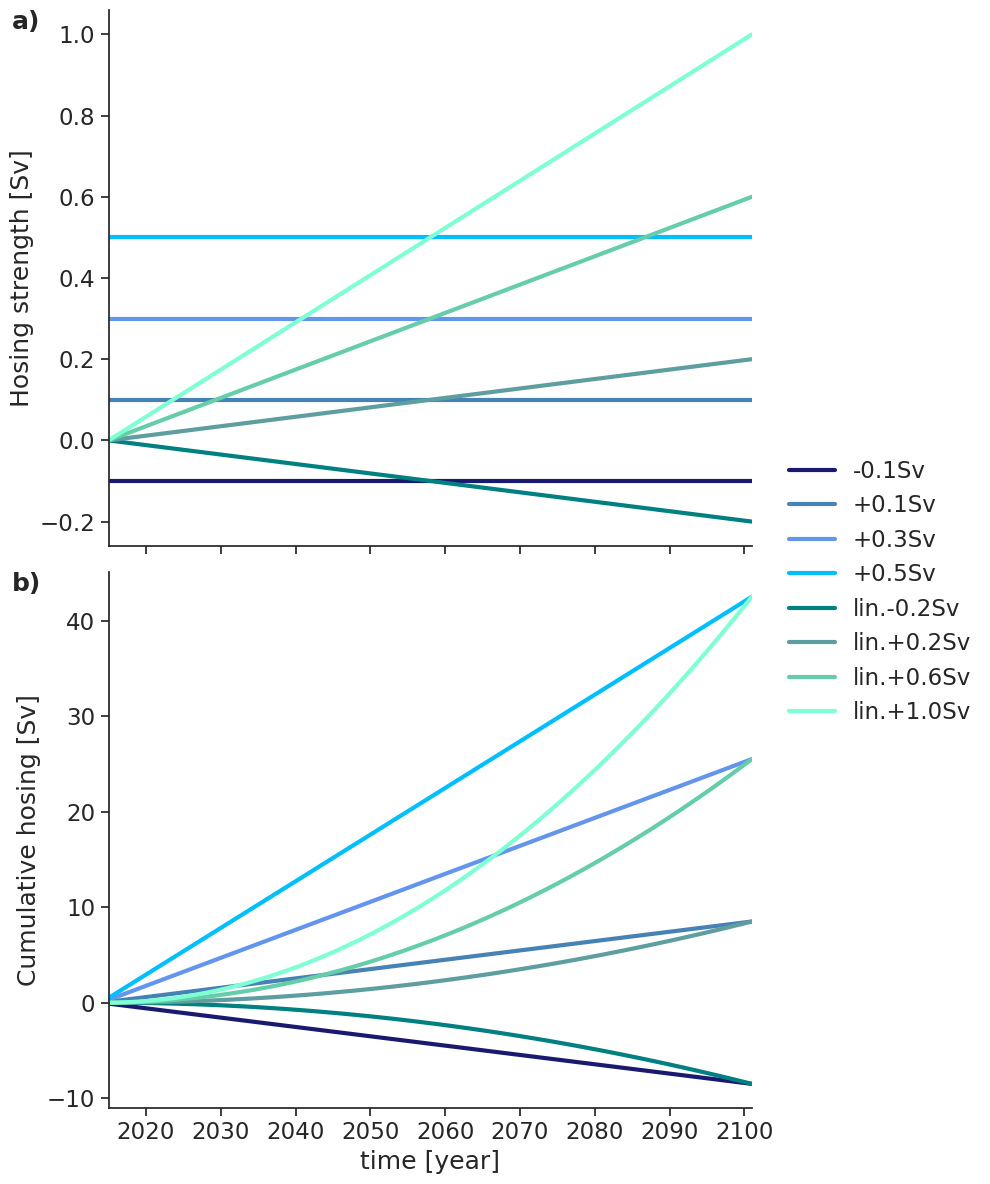

In [ ]:
# Plot the hosing forcing and cumulative forcing time series

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

years = np.linspace(2015, 2101, 85)
ax1.plot(years, np.ones_like(years) * -0.1, linewidth=3, label='-0.1Sv', color=colors['neg01'])
ax1.plot(years, np.ones_like(years) * 0.1, linewidth=3, label='+0.1Sv', color=colors['01'])
ax1.plot(years, np.ones_like(years) * 0.3, linewidth=3, label='+0.3Sv', color=colors['03'])
ax1.plot(years, np.ones_like(years) * 0.5, linewidth=3, label='+0.5Sv', color=colors['05'])
ax1.plot(years, np.linspace(0, -0.2, 85), linewidth=3, label='lin.-0.2Sv', color=colors['linneg02'])
ax1.plot(years, np.linspace(0, 0.2, 85), linewidth=3, label='lin.+0.2Sv', color=colors['lin02'])
ax1.plot(years, np.linspace(0, 0.6, 85), linewidth=3, label='lin.+0.6Sv', color=colors['lin06'])
ax1.plot(years, np.linspace(0, 1.0, 85), linewidth=3, label='lin.+1.0Sv', color=colors['lin10'])
ax1.set_xlim(2015, 2101)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel("Hosing strength [Sv]")
#ax1.legend(frameon=False)
ax1.set_yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.text(-0.15, 1, 'a)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

ax2.plot(years, np.cumsum(np.ones_like(years) * -0.1), linewidth=3, label='-0.1Sv', color=colors['neg01'])
ax2.plot(years, np.cumsum(np.ones_like(years) * 0.1), linewidth=3, label='+0.1Sv', color=colors['01'])
ax2.plot(years, np.cumsum(np.ones_like(years) * 0.3), linewidth=3, label='+0.3Sv', color=colors['03'])
ax2.plot(years, np.cumsum(np.ones_like(years) * 0.5), linewidth=3, label='+0.5Sv', color=colors['05'])
ax2.plot(years, np.cumsum(np.linspace(0, -0.2, 85)), linewidth=3, label='lin.-0.2Sv', color=colors['linneg02'])
ax2.plot(years, np.cumsum(np.linspace(0, 0.2, 85)), linewidth=3, label='lin.+0.2Sv', color=colors['lin02'])
ax2.plot(years, np.cumsum(np.linspace(0, 0.6, 85)), linewidth=3, label='lin.+0.6Sv', color=colors['lin06'])
ax2.plot(years, np.cumsum(np.linspace(0, 1.0, 85)), linewidth=3, label='lin.+1.0Sv', color=colors['lin10'])
ax2.set_xlim(2015, 2101)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylabel("Cumulative hosing [Sv]")
ax2.set_xlabel("time [year]")
#ax2.legend(frameon=False)
ax2.text(-0.15, 1, 'b)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False, bbox_to_anchor=(1.25, 0.5))
plt.tight_layout()
plt.show()
fig.savefig('../plots/hosing_forcing.pdf', bbox_inches='tight', transparent=True)

## Sea ice concentration plot (Fig. A7)

In [ ]:
# Load siconc data for the NAHOSMIP models
models = ["CanESM5", "CESM2", "EC-Earth3", "HadGEM3-GC3-1LL", "HadGEM3-GC3-1MM", "IPSL-CM6A-LR", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR"]
path = "/work/uo1075/m300817/hosing/nahosmip/" 
siconc_nahosmip = {}
for model in models:
    ds =  xr.open_mfdataset(path+f"/{model}/u03-hos/*siconc*.nc", use_cftime=True, parallel=True)
    if 'lon' in ds.coords:
        lon_coord = 'lon'
    elif 'longitude' in ds.coords:
        lon_coord = 'longitude'
    else:
        # Handle case where longitude coordinate has a different name
        lon_coord = None
        for coord in ds.coords:
            if 'lon' in coord.lower():
                lon_coord = coord
                break
    
    if lon_coord and ds[lon_coord].max() > 180:
        # Convert from 0-360 to -180-180
        ds = ds.assign_coords({lon_coord: (ds[lon_coord] + 180) % 360 - 180})
        ds = ds.sortby(lon_coord)
    
    siconc_nahosmip[model] = ds

In [ ]:
# Create functions to find the sea ice concentration variable and time dimension in the dataset
possible_var_names = ['siconc', 'aice', 'soicecov']   # Define possible variable names for sea ice concentration
possible_time_names = ['time', 'time_counter']   # Define possible time dimension names

def get_siconc_variable(ds, possible_names):
    """Find the sea ice concentration variable in the dataset"""
    for var_name in possible_names:
        if var_name in ds.variables:
            return var_name
    
    # If none found, look for variables with 'ice' and 'conc' in the name
    for var_name in ds.variables:
        if 'ice' in var_name.lower() and 'conc' in var_name.lower():
            return var_name
    
    # If still nothing, look for any variable with 'ice' in the name
    for var_name in ds.variables:
        if 'ice' in var_name.lower():
            return var_name
    
    # Last resort: print available variables and return None
    print(f"Could not find sea ice concentration variable. Available variables: {list(ds.variables.keys())}")
    return None

def get_time_dimension(ds, possible_names):
    """Find the time dimension in the dataset"""
    for time_name in possible_names:
        if time_name in ds.dims:
            return time_name
    
    # If none found, look for dimensions with 'time' in the name
    for dim_name in ds.dims:
        if 'time' in dim_name.lower():
            return dim_name
    
    # Last resort: print available dimensions and return None
    print(f"Could not find time dimension. Available dimensions: {list(ds.dims.keys())}")
    return None

/tmp/ipykernel_2878459/1815676334.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


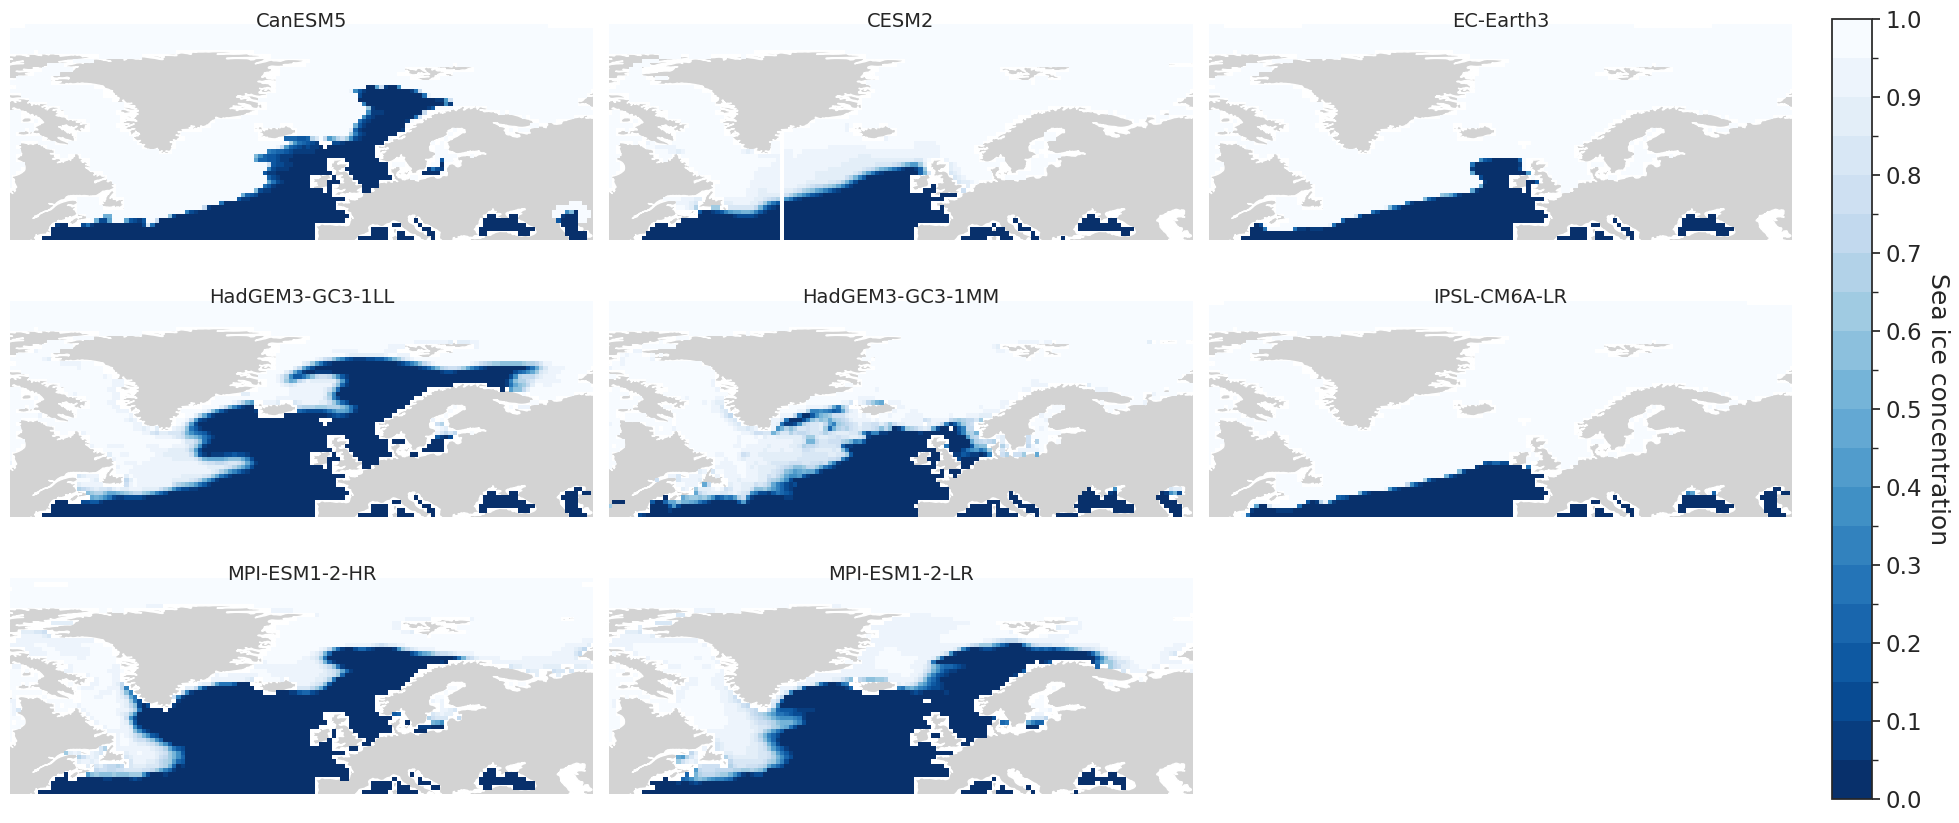

In [ ]:
# Define North Atlantic Arctic region bounds
lat_min, lat_max = 40, 90
lon_min, lon_max = -80, 55

# Create subplot figure
fig = plt.figure(figsize=(20, 13))
n_cols = 3
n_rows = 3
for i, model in enumerate(models):
    ds = siconc_nahosmip[model]
    var_name = get_siconc_variable(ds, possible_var_names)
    time_dim = get_time_dimension(ds, possible_time_names)
    ds_region = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    ds_last5 = ds_region[var_name].isel({time_dim: slice(95, 100)}).mean(dim=time_dim)
    ds_first5 = ds_region[var_name].isel({time_dim: slice(0, 5)}).mean(dim=time_dim)
    year = 99
    siconc_plot = ds_region[var_name].isel({time_dim: year})
    
    ax = fig.add_subplot(n_rows, n_cols, i+1, projection=ccrs.PlateCarree())

    im = siconc_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues_r', 
                          vmin=0, vmax=1, levels=np.linspace(0.,1,21), add_colorbar=False)
    
    #ax.coastlines()
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.OCEAN, color='white')
    
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], ccrs.PlateCarree())
    ax.set_title(f'{model}', fontsize=14, y=0.95)
    ax.set_frame_on(False)
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
cbar.set_label('Sea ice concentration', rotation=270, labelpad=20)

plt.tight_layout()
plt.subplots_adjust(hspace=-0.61, right=0.9)
plt.show()
fig.savefig('../plots/seaiceconc_100y.pdf', bbox_inches='tight', transparent=True)

## ERA5 rank histogram plot (Fig. A16)

In [ ]:
# load historical and ERA5 temperature data for annual temperature time series over European land

outpath = f"/work/uo1075/m300817/teu_amoc/data/MPI-GE/"
his_tas_eur_yr = xr.open_dataarray(outpath+"his_tas_eur_yr.nc", use_cftime=True).to_dataset(name='tas')

era5_tas_yr = xr.open_mfdataset("/work/uo1075/m300817/teu_amoc/data/ERA5/tas_yr_era_*.nc", use_cftime=True) 
mask_eur = regionmask.defined_regions.ar6.land[16, 17, 18, 19].mask(era5_tas_yr)  # Europe
mask_land = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(era5_tas_yr) # Natural earth masks
era5_tas_eur_yr = era5_tas_yr.where(mask_eur>15, drop=True).where(mask_land==0, drop=True)

/tmp/ipykernel_2878459/2807962710.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


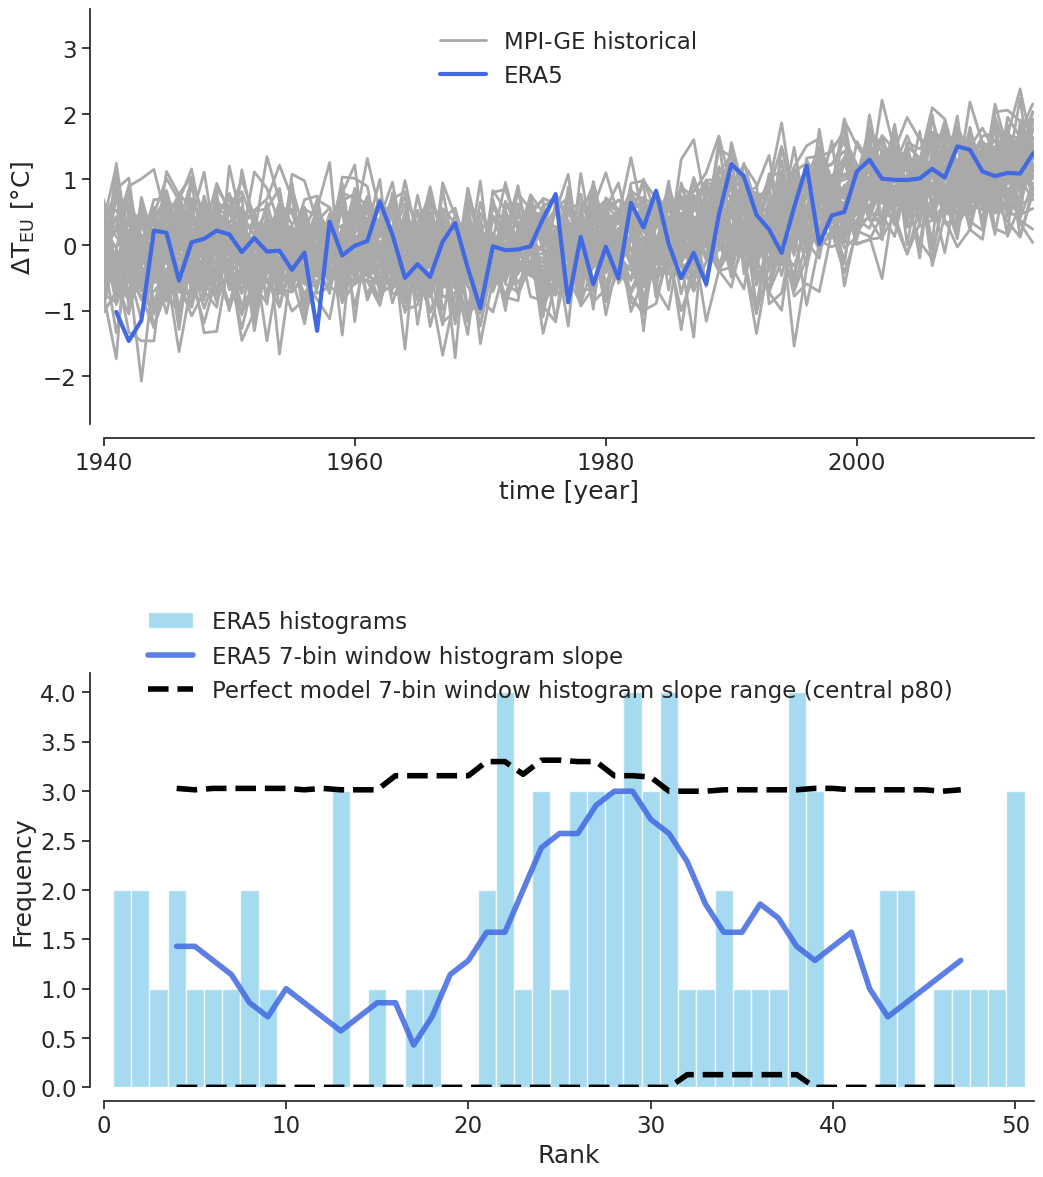

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), gridspec_kw={'hspace': 0.6})

# Top subplot - time series
first_plot = True
for rea in his_tas_eur_yr.realiz:
    ref19601989_gehiseur = weighted_area_lat(his_tas_eur_yr.sel(realiz=rea)).mean('lat').mean('lon').sel(
        time=slice(cftime.DatetimeProlepticGregorian(1960, 1, 1),cftime.DatetimeProlepticGregorian(1989, 12, 31))).mean('time').tas.values
    label = 'MPI-GE historical' if first_plot else None
    (weighted_area_lat(his_tas_eur_yr.sel(realiz=rea)).mean('lat').mean('lon').tas-ref19601989_gehiseur).plot(ax=ax1, color='darkgrey', label=label, linewidth=2)
    first_plot = False
ref19601989_eraeur = weighted_area_lat(era5_tas_eur_yr).mean('lat').mean('lon').sel(
    time=slice(cftime.DatetimeProlepticGregorian(1960, 1, 1),cftime.DatetimeProlepticGregorian(1989, 12, 31))).mean('time').tas.values
(weighted_area_lat(era5_tas_eur_yr).mean('lat').mean('lon').tas-ref19601989_eraeur).plot(ax=ax1, color='royalblue', label='ERA5', linewidth=3)
ax1.set_xlabel("time [year]")
ax1.set_xlim([cftime.DatetimeProlepticGregorian(1940, 1, 1),cftime.DatetimeProlepticGregorian(2014, 1, 31)])
ax1.legend(loc=9, frameon=False)
ax1.set_ylabel(r"$\Delta \mathrm{T}_{\mathrm{EU}}$ [°C]")
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 10))

# Bottom subplot - rank histogram
hisref1960 = weighted_area_lat(his_tas_eur_yr).mean('lat').mean('lon').mean("realiz").sel(time=slice(cftime.DatetimeProlepticGregorian(1960, 1, 1),cftime.DatetimeProlepticGregorian(1989, 12, 31))).mean('time').tas.values
his_tas_eur_yr_anom = weighted_area_lat(his_tas_eur_yr).mean('lat').mean('lon').tas.sel(
        time=slice(cftime.DatetimeProlepticGregorian(1940, 1, 1),cftime.DatetimeProlepticGregorian(2014, 12, 31)))-hisref1960
eraref1960 = weighted_area_lat(era5_tas_eur_yr).mean('lat').mean('lon').sel(time=slice(cftime.DatetimeProlepticGregorian(1960, 1, 1),cftime.DatetimeProlepticGregorian(1989, 12, 31))).mean('time').tas.values
era5_tas_eur_yr_anom = weighted_area_lat(era5_tas_eur_yr).mean('lat').mean('lon').sel(
        time=slice(cftime.DatetimeProlepticGregorian(1940, 1, 1),cftime.DatetimeProlepticGregorian(2014, 12, 31))).tas-eraref1960

ranks_era = np.zeros_like(era5_tas_eur_yr_anom.values)
for i, tas_era in enumerate(era5_tas_eur_yr_anom.values):
    combined = [tas_era]
    for rea in his_tas_eur_yr_anom.realiz:
        combined.append(float(his_tas_eur_yr_anom.sel(realiz=rea).isel(time=i).values))
    ranked = stats.rankdata(combined, method='average')
    ranks_era[i] = ranked[0]

freq_table = np.zeros((50, 50))
rank_tas_realiz = his_tas_eur_yr_anom.rank(dim='realiz')
for i, rea in enumerate(his_tas_eur_yr_anom.realiz):
    freq, bin_edges = np.histogram(rank_tas_realiz.sel(realiz=rea), bins=np.arange(1, 52)-0.5)
    freq_table[i, :] = freq
    
freq_model10 = []
freq_model90 = []
for j, rea in enumerate(his_tas_eur_yr_anom.realiz):
    freq_model10.append(np.quantile(freq_table[:, j], 0.1))
    freq_model90.append(np.quantile(freq_table[:, j], 0.9))

hist, bin_edges = np.histogram(ranks_era, bins=np.arange(1, 52)-0.5)
ax2.hist(ranks_era, bins=np.arange(52)-0.5, alpha=0.75, label='ERA5 histograms', color='skyblue')

mean_freq = np.convolve(hist, np.ones(7)/7, mode='valid')
ax2.plot(np.arange(4, 48), mean_freq, alpha=0.85, color='royalblue', label='ERA5 7-bin window histogram slope', linewidth=4)

ax2.plot(np.arange(4, 48), np.convolve(freq_model10, np.ones(7)/7, mode='valid'), 
         linestyle='dashed', color='black', linewidth=4)
ax2.plot(np.arange(4, 48), np.convolve(freq_model90, np.ones(7)/7, mode='valid'),
         linestyle='dashed', color='black', linewidth=4, label='Perfect model 7-bin window histogram slope range (central p80)')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Frequency')
ax2.set_xlim(0, 51)
ax2.legend(loc=9, bbox_to_anchor=(0.48, 1.2), frameon=False)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

plt.tight_layout()
plt.show()
fig.savefig('../plots/rank_histograms.pdf', bbox_inches='tight', transparent=True)

## CO2 forcings plot (Fig. A17)

In [ ]:
# Load greenhouse gas concentration data for the SSP scenarios
ssp119 = xr.open_mfdataset("/pool/data/ECHAM6/input/r0008/greenhouse_ssp119.nc")
ssp126 = xr.open_mfdataset("/pool/data/ECHAM6/input/r0008/greenhouse_ssp126.nc")
ssp245 = xr.open_mfdataset("/pool/data/ECHAM6/input/r0008/greenhouse_ssp245.nc")
ssp370 = xr.open_mfdataset("/pool/data/ECHAM6/input/r0008/greenhouse_ssp370.nc")
ssp585 = xr.open_mfdataset("/pool/data/ECHAM6/input/r0008/greenhouse_ssp585.nc")

exps = {
    "SSP1-2.6": ssp126.isel(lat=0).isel(lon=0),
    "SSP2-4.5": ssp245.isel(lat=0).isel(lon=0),
    "SSP3-7.0": ssp370.isel(lat=0).isel(lon=0),
}

ssp_col = { 
           "SSP1-2.6": (23/255,60/255,102/255),
           "SSP2-4.5": (247/255,148/255,32/255),
           "SSP3-7.0": (231/255,29/255,37/255),
          }

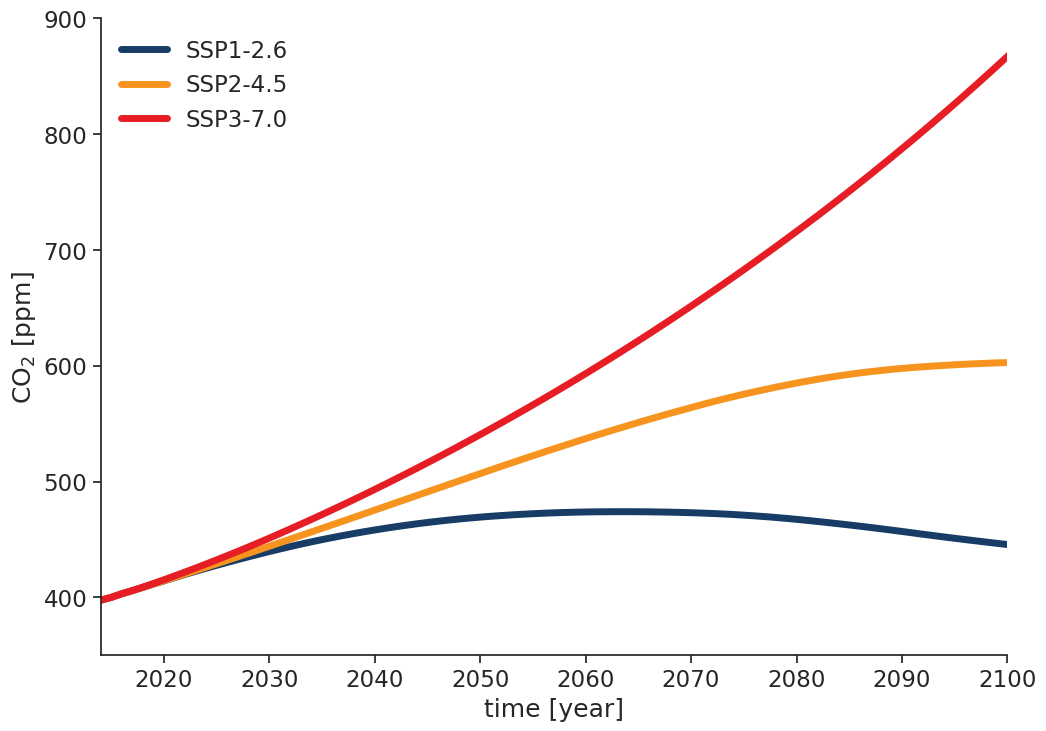

In [ ]:
# Plot the CO2 concentration time series
fig, ax = plt.subplots()
for name, exp in exps.items():
    exp.CO2.plot(color=ssp_col[name], label=name, linewidth=5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(2014, 2100)
plt.ylim(350, 900)
plt.legend(frameon=False)
plt.title("")
plt.ylabel("CO$_2$ [ppm]")
plt.xlabel("time [year]")
plt.show()
fig.savefig('../plots/co2_forcing.pdf', bbox_inches='tight', transparent=True)